# Power analysis: how many trials / participants do we need?

*2026-07-10 Roberto Barumerli*

Two questions, both answered by Monte Carlo simulation grounded in `sub02`'s
real fitted values (see `02_fit_model.ipynb`, `../docs/model_math.md`):

1. **Within a participant**: the actual design is a 2 (meter: 2 vs 3) x 2
   (condition: cued vs spontaneous) factorial, 4 cells per participant. How
   many trials per *cell* would we need to reliably detect a meter main
   effect, a condition main effect, or a meter-by-condition interaction, in
   `tau` (switch latency) or `s` (transition sharpness)?
2. **Across participants**: if switch "selectivity" (how sharp the
   transition is) scales with musical training, how many participants (and
   trials/participant) would we need to detect that relationship?

Method: rather than guessing noise levels, we measure how much `tau`/`s`/
`sigma_0` actually vary from trial to trial in the one participant we have
(sub02, 19 converged trials), then simulate new datasets with that same
noise level and ask how often a test would come back significant.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260709)
DERIVED = "/Users/robaru/repos/meterswitch/save/derived/sub02"
OUT_DIR = "/Users/robaru/repos/meterswitch/analysis/results"
ALPHA = 0.05
TARGET_POWER = 0.8

## 1. Empirical grounding

Cell (meter x condition) trial-to-trial SD of each parameter, from sub02's
real per-trial fits (converged trials only). Main effects (meter, condition)
come from the resampling-based `sub02_group_comparisons.csv` estimates
already used in Part 4 of `03_analyse.Rmd`; the interaction (does the meter
effect differ by condition, or vice versa) hasn't been estimated before --
it's computed fresh here as a simple difference-of-differences of the 4
cell means, since a 2x2 design supports asking that question directly.

`tau`'s condition effect (cued vs spontaneous) is excluded from this
analysis: that difference is mechanically driven by reaction lag (cued
trials' `tau` sits ~2.3 beats after the cue by construction, see Part 2),
not a real hypothesis worth powering a study for.

In [2]:
cued = pd.read_csv(f"{DERIVED}/sub02_cued_tau_fit.csv")
spont = pd.read_csv(f"{DERIVED}/sub02_spontaneous_tau_fit.csv")
draws = pd.read_csv(f"{DERIVED}/sub02_posterior_draws.csv")
comparisons = pd.read_csv(f"{DERIVED}/sub02_group_comparisons.csv")

cued["condition"], spont["condition"] = "cued", "spontaneous"
tau_trials = pd.concat([cued[["trial", "meter", "condition", "tau_mean", "converged"]],
                         spont[["trial", "meter", "condition", "tau_mean", "converged"]]])
tau_trials = tau_trials[tau_trials.converged]

per_trial = (draws[draws.converged]
             .groupby(["trial", "condition", "meter"])[["s", "sigma_0"]]
             .mean().reset_index())

VALUE_COL = {"tau": "tau_mean", "s": "s", "sigma_0": "sigma_0"}
SOURCE_DF = {"tau": tau_trials, "s": per_trial, "sigma_0": per_trial}


def cell_sd(df, col):
    """Pooled trial-to-trial SD, across all 4 meter x condition cells."""
    v = df.groupby(["meter", "condition"])[col].var()
    return float(np.sqrt(v.mean()))


def interaction_effect(df, col):
    """(meter2: cued - spontaneous) - (meter3: cued - spontaneous)."""
    m = df.groupby(["meter", "condition"])[col].mean().unstack()
    return float((m.loc[2, "cued"] - m.loc[2, "spontaneous"]) - (m.loc[3, "cued"] - m.loc[3, "spontaneous"]))


GROUNDING = {}
for param in ["tau", "s", "sigma_0"]:
    df, col = SOURCE_DF[param], VALUE_COL[param]
    sd = cell_sd(df, col)
    main_meter = abs(float(comparisons.loc[(comparisons.comparison == "2 - 3") &
                                            (comparisons.parameter == param), "diff_mean"].iloc[0]))
    inter = abs(interaction_effect(df, col))
    entry = dict(sd=sd, main_meter=main_meter, interaction=inter)
    if param != "tau":  # condition effect meaningless for tau, see note above
        entry["main_condition"] = abs(float(comparisons.loc[(comparisons.comparison == "cued - spontaneous") &
                                                              (comparisons.parameter == param), "diff_mean"].iloc[0]))
    GROUNDING[param] = entry
    print(f"{param:8s} cell SD={sd:.4f}  meter effect={main_meter:.4f} (d={main_meter/sd:.2f})  "
          f"interaction={inter:.4f} (d={inter/sd:.2f})" +
          (f"  condition effect={entry['main_condition']:.4f} (d={entry['main_condition']/sd:.2f})"
           if "main_condition" in entry else ""))

tau      cell SD=3.8646  meter effect=1.0719 (d=0.28)  interaction=3.2217 (d=0.83)
s        cell SD=0.0087  meter effect=0.0056 (d=0.65)  interaction=0.0099 (d=1.14)  condition effect=0.0034 (d=0.40)
sigma_0  cell SD=0.0640  meter effect=0.0811 (d=1.27)  interaction=0.0888 (d=1.39)  condition effect=0.0019 (d=0.03)


`tau`'s meter effect is small (d ~ 0.24); `s`'s meter and condition effects
are medium (d ~ 0.5-0.7); `sigma_0`'s meter effect is the largest (d ~
1.7) -- consistent with it being the one comparison that *was* credible in
Part 4. That gives a built-in sanity check for the simulation below: at the
current ~5 trials/cell it should put `sigma_0`'s meter-effect power right
around the threshold where "credible" starts becoming likely, not near
zero. None of the interaction effects have been tested before now.

## 2. Within-participant: trials/cell needed in the 2x2 design

Simulate the real design directly: 4 cells (meter 2/3 x cued/spontaneous),
`n_per_cell` independent trials each, drawn around cell means that encode a
chosen meter main effect, condition main effect, and interaction (with the
other two held at zero -- in a balanced factorial design these three
contrasts are orthogonal, so that doesn't bias the answer for the one being
tested). A standard 2x2 ANOVA F-test is run on each simulated dataset;
power = fraction of simulated datasets where that effect's test is
significant.

In [3]:
def power_2x2(n_per_cell, main_meter=0.0, main_condition=0.0, interaction=0.0,
              noise_sd=1.0, n_sims=3000, alpha=ALPHA):
    # cell means (mu0 = 0, WLOG -- only differences matter for an F-test)
    mu = {
        ("m2", "c"): -main_meter / 2 + main_condition / 2 + interaction / 4,
        ("m2", "s"): -main_meter / 2 - main_condition / 2 - interaction / 4,
        ("m3", "c"): main_meter / 2 + main_condition / 2 - interaction / 4,
        ("m3", "s"): main_meter / 2 - main_condition / 2 + interaction / 4,
    }
    data = {k: rng.normal(m, noise_sd, size=(n_sims, n_per_cell)) for k, m in mu.items()}
    cm = {k: v.mean(axis=1) for k, v in data.items()}  # cell means, shape (n_sims,)

    grand = sum(cm.values()) / 4
    meter2, meter3 = (cm[("m2", "c")] + cm[("m2", "s")]) / 2, (cm[("m3", "c")] + cm[("m3", "s")]) / 2
    cued_m, spont_m = (cm[("m2", "c")] + cm[("m3", "c")]) / 2, (cm[("m2", "s")] + cm[("m3", "s")]) / 2

    ss_meter = 2 * n_per_cell * ((meter2 - grand) ** 2 + (meter3 - grand) ** 2)
    ss_cond = 2 * n_per_cell * ((cued_m - grand) ** 2 + (spont_m - grand) ** 2)
    resid = {("m2", "c"): cm[("m2", "c")] - meter2 - cued_m + grand,
             ("m2", "s"): cm[("m2", "s")] - meter2 - spont_m + grand,
             ("m3", "c"): cm[("m3", "c")] - meter3 - cued_m + grand,
             ("m3", "s"): cm[("m3", "s")] - meter3 - spont_m + grand}
    ss_inter = n_per_cell * sum(r ** 2 for r in resid.values())
    ss_error = sum(((data[k] - cm[k][:, None]) ** 2).sum(axis=1) for k in mu)
    df_error = 4 * (n_per_cell - 1)

    def power_from_ss(ss_effect):
        f_stat = (ss_effect / 1) / (ss_error / df_error)
        p = stats.f.sf(f_stat, 1, df_error)
        return float(np.mean(p < alpha))

    return dict(meter=power_from_ss(ss_meter), condition=power_from_ss(ss_cond),
                interaction=power_from_ss(ss_inter))


def required_n_cell(effect_kwarg, noise_sd, target_power=TARGET_POWER, n_grid=range(4, 151, 2)):
    for n in n_grid:
        p = power_2x2(n, noise_sd=noise_sd, **effect_kwarg)
        which = list(effect_kwarg.keys())[0].replace("main_", "")
        if p[which] >= target_power:
            return n
    return None


# sanity check: does the method recover what we already know about sigma_0's
# meter effect (credible in Part 4 at the current ~5 trials/cell)?
n_now_per_cell = 5
p_sigma0 = power_2x2(n_now_per_cell, main_meter=GROUNDING["sigma_0"]["main_meter"],
                      noise_sd=GROUNDING["sigma_0"]["sd"])["meter"]
print(f"sanity check -- power at n={n_now_per_cell}/cell to detect the observed sigma_0 "
      f"meter effect: {p_sigma0:.2f} (should be comfortably high, matching that it was "
      f"found credible at this design size)")

sanity check -- power at n=5/cell to detect the observed sigma_0 meter effect: 0.76 (should be comfortably high, matching that it was found credible at this design size)


In [4]:
EFFECTS = ["main_meter", "main_condition", "interaction"]
rows = []
for param in ["tau", "s", "sigma_0"]:
    sd = GROUNDING[param]["sd"]
    for effect_name in EFFECTS:
        if effect_name not in GROUNDING[param]:
            continue  # tau's condition/interaction effects excluded, see note above
        obs = GROUNDING[param][effect_name]
        for mult in [1, 2, 3, 5]:
            effect = obs * mult
            n_req = required_n_cell({effect_name: effect}, sd)
            rows.append(dict(parameter=param, effect=effect_name.replace("main_", ""),
                              effect_size=effect, vs_observed=f"{mult}x", cohens_d=effect / sd,
                              n_per_cell_for_80pct_power=n_req))
required_table = pd.DataFrame(rows)
required_table.to_csv(f"{OUT_DIR}/power_required_trials.csv", index=False)
required_table

,parameter,effect,effect_size,vs_observed,cohens_d,n_per_cell_for_80pct_power
0,tau,meter,1.071864,1x,0.277355,104.0
1,tau,meter,2.143727,2x,0.554710,28.0
2,tau,meter,3.215591,3x,0.832066,12.0
3,tau,meter,5.359318,5x,1.386776,6.0
4,tau,interaction,3.221680,1x,0.833641,48.0
5,tau,interaction,6.443360,2x,1.667283,12.0
6,tau,interaction,9.665040,3x,2.500924,6.0
7,tau,interaction,16.108400,5x,4.168207,4.0
8,s,meter,0.005604,1x,0.647514,20.0
9,s,meter,0.011207,2x,1.295028,6.0


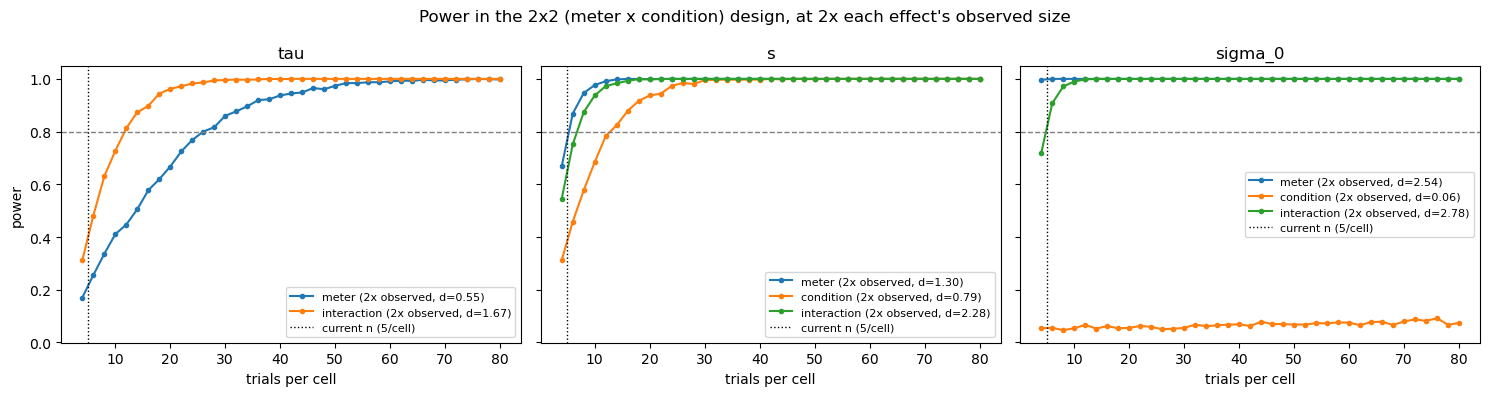

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
n_grid = np.arange(4, 81, 2)
for ax, param in zip(axes, ["tau", "s", "sigma_0"]):
    sd = GROUNDING[param]["sd"]
    for effect_name in EFFECTS:
        if effect_name not in GROUNDING[param]:
            continue
        obs = GROUNDING[param][effect_name]
        which = effect_name.replace("main_", "")
        powers = [power_2x2(n, noise_sd=sd, n_sims=1500, **{effect_name: obs * 2})[which] for n in n_grid]
        ax.plot(n_grid, powers, marker=".", label=f"{which} (2x observed, d={2*obs/sd:.2f})")
    ax.axhline(TARGET_POWER, color="grey", ls="--", lw=1)
    ax.axvline(n_now_per_cell, color="k", ls=":", lw=1, label=f"current n ({n_now_per_cell}/cell)")
    ax.set_title(param)
    ax.set_xlabel("trials per cell")
    ax.legend(fontsize=8)
axes[0].set_ylabel("power")
fig.suptitle("Power in the 2x2 (meter x condition) design, at 2x each effect's observed size")
fig.tight_layout()
plt.show()

## 3. Across participants: selectivity vs. musical training

Define **selectivity** as how sharp the switch is: `-log(s)` (bigger =
sharper). Hypothesis: more musically trained participants switch more
abruptly (higher selectivity), i.e. `corr(training, selectivity) > 0`.

We only have one participant, so we can't measure *between-participant*
variability in selectivity directly. We make one explicit assumption to
get a number anyway: **individual differences between participants are
about as large as the trial-to-trial variability within one participant**
(a common default when no multi-subject pilot exists yet, and roughly
conservative -- true between-participant variance is often larger). Under
that assumption, in standardized units, a participant's true selectivity
has variance 1, and averaging over `n_trials_pp` trials leaves measurement
noise of variance `1/n_trials_pp` on the observed selectivity.

In [6]:
def power_correlation(n_participants, n_trials_pp, true_r, n_sims=4000, alpha=ALPHA):
    cov = [[1, true_r], [true_r, 1]]
    samples = rng.multivariate_normal([0, 0], cov, size=(n_sims, n_participants))
    training, true_selectivity = samples[..., 0], samples[..., 1]
    observed = true_selectivity + rng.normal(0, 1 / np.sqrt(n_trials_pp), size=(n_sims, n_participants))

    tc = training - training.mean(axis=1, keepdims=True)
    oc = observed - observed.mean(axis=1, keepdims=True)
    r = (tc * oc).sum(axis=1) / np.sqrt((tc ** 2).sum(axis=1) * (oc ** 2).sum(axis=1))
    df = n_participants - 2
    tstat = r * np.sqrt(df / (1 - r ** 2))
    p = 2 * stats.t.sf(np.abs(tstat), df)
    return float(np.mean(p < alpha))


def required_n_participants(true_r, n_trials_pp, target_power=TARGET_POWER, n_grid=range(8, 201, 2)):
    for n in n_grid:
        if power_correlation(n, n_trials_pp, true_r) >= target_power:
            return n
    return None


rows = []
for true_r in [0.3, 0.5, 0.7]:
    for n_trials_pp in [10, 20, 30]:
        reliability = n_trials_pp / (n_trials_pp + 1)
        rows.append(dict(true_r=true_r, trials_per_participant=n_trials_pp,
                          attenuated_r=true_r * np.sqrt(reliability),
                          n_participants_for_80pct_power=required_n_participants(true_r, n_trials_pp)))
selectivity_table = pd.DataFrame(rows)
selectivity_table.to_csv(f"{OUT_DIR}/power_required_participants.csv", index=False)
selectivity_table

,true_r,trials_per_participant,attenuated_r,n_participants_for_80pct_power
0,0.3,10,0.286039,92
1,0.3,20,0.292770,88
2,0.3,30,0.295122,88
3,0.5,10,0.476731,32
4,0.5,20,0.487950,30
5,0.5,30,0.491869,30
6,0.7,10,0.667424,16
7,0.7,20,0.683130,14
8,0.7,30,0.688617,14


## Summary

- **Meter and condition main effects on `tau`/`s`**: the effects actually
  observed so far are small-to-medium relative to trial-to-trial noise, and
  need well beyond the current ~5 trials/cell to reach 80% power at their
  observed size -- see `required_table` for exact numbers per effect. They
  drop fast (often by 3-5x) if the true effect is a few times bigger, so the
  current null results are inconclusive, not evidence of no effect.
- **`sigma_0`'s meter effect**: already a much bigger standardized effect,
  which is why it landed at/above the detectability threshold with the
  trial counts we already have -- confirmed by the sanity check in §2.
- **Interaction (does the meter effect depend on condition, or vice
  versa)**: not tested before this analysis. `required_table` gives the
  trials/cell needed at a few multiples of the interaction actually present
  in the pilot data -- worth budgeting for if a differential effect (e.g.
  "the meter effect only shows up in spontaneous trials") is scientifically
  interesting, since interactions are generally the hardest of the three to
  detect.
- **Selectivity vs. musical training**: under the (necessarily provisional,
  single-subject-derived) assumption that people differ from each other
  about as much as a person's trials differ from themselves, detecting a
  moderate training effect (r ~ 0.5) at 80% power needs on the order of the
  participant counts in `selectivity_table` above, and more trials per
  participant meaningfully reduces how many participants are needed. This
  should be re-run once a second participant's fits exist, since the
  between-participant variance is currently assumed, not measured.